In [1]:
%matplotlib inline
# Cell 1
import time
import warnings
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import inv
from pathlib import Path

import scripts.shared.db_utils as db_utils
conn = db_utils.db_connect()

ROOT = Path(db_utils.__file__).parent.parent.parent
OUT  = ROOT / 'output' / 'edop' / 'demo'
OUT.mkdir(parents=True, exist_ok=True)

print('connected')
print('output ->', OUT)

connected
output -> /Users/karlg/Documents/repos/_edops/output/edop/demo


In [2]:
# Cell 2 — Load L08 monthly arrays
# Question A: how big is the L08 load?

t0 = time.perf_counter()
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', message='pandas only supports SQLAlchemy')
    arr08 = pd.read_sql(
        'SELECT hybas_id, pre_mm_monthly, tmp_dc_monthly '
        'FROM public.v_basin08_persist_rev2',
        conn,
    )
t_load = time.perf_counter() - t0

hybas_ids_08 = arr08['hybas_id'].to_numpy().astype(np.int64)
PRE08 = np.array(arr08['pre_mm_monthly'].tolist(), dtype=float)   # (N, 12)
TMP08 = np.array(arr08['tmp_dc_monthly'].tolist(), dtype=float)   # (N, 12) — already °C

mem_arrays = (PRE08.nbytes + TMP08.nbytes) / 1e6
print(f'L08 basins loaded: {len(hybas_ids_08):,}')
print(f'Load time:         {t_load:.1f} s')
print(f'PRE+TMP arrays:    {mem_arrays:.1f} MB')
print(f'NaN in PRE:        {np.isnan(PRE08).any(axis=1).sum():,} basins')
print(f'NaN in TMP:        {np.isnan(TMP08).any(axis=1).sum():,} basins')

L08 basins loaded: 190,675
Load time:         2.4 s
PRE+TMP arrays:    36.6 MB
NaN in PRE:        0 basins
NaN in TMP:        0 basins


In [3]:
# Cell 3 — Compute derived variables at L08
# Same logic as seasonality.py _compute_derived(); reproduced here for timing isolation

_TWO_PI = 2 * np.pi
_THETA  = np.array([_TWO_PI * m / 12 for m in range(12)])

def circ_conc_angle(W):
    total = W.sum(axis=1, keepdims=True)
    total = np.where(total == 0, np.nan, total)
    Rx = (W * np.cos(_THETA)).sum(axis=1) / total[:, 0]
    Ry = (W * np.sin(_THETA)).sum(axis=1) / total[:, 0]
    return np.sqrt(Rx**2 + Ry**2), np.arctan2(Ry, Rx)

t0 = time.perf_counter()
pre_conc, pre_angle = circ_conc_angle(PRE08)
TMP_shifted = TMP08 - TMP08.min(axis=1, keepdims=True)
tmp_conc, tmp_angle = circ_conc_angle(TMP_shifted)
delta = np.abs(pre_angle - tmp_angle)
delta = np.minimum(delta, _TWO_PI - delta)
seas_phase_offset = delta / _TWO_PI * 12
tmp_seas_amp = TMP08.max(axis=1) - TMP08.min(axis=1)
t_derived = time.perf_counter() - t0

derived08 = {
    'pre_concentration': pre_conc,
    'seas_phase_offset': seas_phase_offset,
    'tmp_concentration': tmp_conc,
    'tmp_seas_amp':      tmp_seas_amp,
}

mem_derived = sum(v.nbytes for v in derived08.values()) / 1e6
print(f'Derived compute time: {t_derived:.2f} s')
print(f'Derived arrays:       {mem_derived:.1f} MB')
for k, v in derived08.items():
    print(f'  {k}: {np.isnan(v).sum():,} NaN ({np.isnan(v).mean()*100:.1f}%)')

Derived compute time: 0.03 s
Derived arrays:       6.1 MB
  pre_concentration: 719 NaN (0.4%)
  seas_phase_offset: 719 NaN (0.4%)
  tmp_concentration: 0 NaN (0.0%)
  tmp_seas_amp: 0 NaN (0.0%)


In [4]:
# Cell 4 — Load L08 scalar columns needed by active lenses
# pre_mm_syr (climate.precip, climate.temp) and tmp_dc_syr (climate.temp) from basin08

t0 = time.perf_counter()
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', message='pandas only supports SQLAlchemy')
    sc08 = pd.read_sql(
        'SELECT hybas_id, pre_mm_syr, tmp_dc_syr FROM public.basin08',
        conn,
    )
t_sc = time.perf_counter() - t0

# Align to array row order
sc08['hybas_id'] = sc08['hybas_id'].astype(np.int64)
order = pd.DataFrame({'hybas_id': hybas_ids_08})
sc08 = order.merge(sc08, on='hybas_id', how='left')

pre_mm_syr_08 = sc08['pre_mm_syr'].to_numpy(dtype=float)
tmp_dc_syr_08 = sc08['tmp_dc_syr'].to_numpy(dtype=float) * 0.1  # stored ×10
pre_mm_syr_08[pre_mm_syr_08 == -9999.0] = np.nan
tmp_dc_syr_08[tmp_dc_syr_08 == -999.9]  = np.nan   # -9999 * 0.1

print(f'Scalars load time: {t_sc:.1f} s')
print(f'pre_mm_syr NaN:    {np.isnan(pre_mm_syr_08).sum():,}')
print(f'tmp_dc_syr NaN:    {np.isnan(tmp_dc_syr_08).sum():,}')

Scalars load time: 1.6 s
pre_mm_syr NaN:    0
tmp_dc_syr NaN:    0


In [5]:
# Cell 5 — Build lens state at L08 for all three active lenses
# Question A continued: how long does the build take? how much memory?

LENS_VARS = {
    'climate.precip': ['pre_mm_syr', 'pre_concentration'],
    'climate.temp':   ['tmp_dc_syr', 'tmp_seas_amp', 'tmp_concentration'],
    'climate.phase':  ['pre_concentration', 'seas_phase_offset'],
}
LENS_METRIC = {
    'climate.precip': 'euclidean',
    'climate.temp':   'mahalanobis',
    'climate.phase':  'euclidean',
}
scalar08 = {
    'pre_mm_syr': pre_mm_syr_08,
    'tmp_dc_syr': tmp_dc_syr_08,
}

def get_col(name):
    return derived08[name] if name in derived08 else scalar08[name]

lens_state08 = {}
total_mem = 0

for lid, vars_ in LENS_VARS.items():
    t0 = time.perf_counter()
    X = np.column_stack([get_col(v) for v in vars_])  # (N, k)
    mask = ~np.isnan(X).any(axis=1)

    if LENS_METRIC[lid] == 'euclidean':
        mu = X[mask].mean(axis=0)
        sd = X[mask].std(axis=0)
        Xz = np.full_like(X, np.nan)
        Xz[mask] = (X[mask] - mu) / sd
        state = {'metric': 'euclidean', 'X_raw': X, 'Xz': Xz}
        mem = (X.nbytes + Xz.nbytes) / 1e6
    else:
        cov = np.cov(X[mask].T)
        VI  = inv(cov)
        state = {'metric': 'mahalanobis', 'X_raw': X, 'VI': VI, 'mask': mask}
        mem = X.nbytes / 1e6  # VI is tiny

    state['variables'] = vars_
    t_build = time.perf_counter() - t0
    lens_state08[lid] = state
    total_mem += mem
    n_valid = int(mask.sum())
    print(f'{lid}: {n_valid:,}/{len(hybas_ids_08):,} valid — build {t_build:.2f} s — {mem:.0f} MB')

print(f'\nTotal lens state memory: {total_mem:.0f} MB')

climate.precip: 189,956/190,675 valid — build 0.01 s — 6 MB
climate.temp: 190,675/190,675 valid — build 0.01 s — 5 MB
climate.phase: 189,956/190,675 valid — build 0.01 s — 6 MB

Total lens state memory: 17 MB


In [6]:
# Cell 6 — Per-query performance at L08
# Use Jerusalem (~35.2°E, 31.8°N) and Timbuktu (~-3.0°W, 16.8°N) as test anchors
# Resolve their L08 hybas_id from the DB, then time a full distance array computation

with warnings.catch_warnings():
    warnings.filterwarnings('ignore', message='pandas only supports SQLAlchemy')
    pts = pd.read_sql("""
        SELECT
            'Jerusalem' AS name, 35.2153 AS lon, 31.7683 AS lat,
            (SELECT hybas_id FROM public.basin08
             WHERE ST_Contains(geom, ST_SetSRID(ST_Point(35.2153, 31.7683), 4326))
             LIMIT 1) AS hybas_id
        UNION ALL
        SELECT
            'Timbuktu', -3.0078, 16.7666,
            (SELECT hybas_id FROM public.basin08
             WHERE ST_Contains(geom, ST_SetSRID(ST_Point(-3.0078, 16.7666), 4326))
             LIMIT 1)
    """, conn)

print(pts.to_string(index=False))

def query_l08(hybas_id, lid):
    state = lens_state08[lid]
    hits = np.where(hybas_ids_08 == int(hybas_id))[0]
    if len(hits) == 0:
        return None, None
    q = int(hits[0])
    t0 = time.perf_counter()
    X_raw = state['X_raw']
    if state['metric'] == 'euclidean':
        Xz = state['Xz']
        diff = Xz - Xz[q]
        dist = np.sqrt(np.nansum(diff**2, axis=1))
        dist[np.isnan(Xz).any(axis=1)] = np.inf
    else:
        diff = X_raw - X_raw[q]
        d2 = np.einsum('ij,jk,ik->i', diff, state['VI'], diff)
        dist = np.where(state['mask'] & (d2 >= 0), np.sqrt(d2), np.inf)
    dist[q] = np.inf
    t_query = time.perf_counter() - t0
    return dist, t_query

print()
for _, row in pts.iterrows():
    if pd.isna(row.hybas_id):
        print(f'{row["name"]}: no L08 basin found')
        continue
    hid = int(row.hybas_id)
    for lid in LENS_VARS:
        dist, t = query_l08(hid, lid)
        if dist is None:
            print(f'{row["name"]} / {lid}: hybas_id {hid} not in index')
        else:
            finite = np.isfinite(dist)
            print(f'{row["name"]:10s} / {lid:18s}: {t*1000:.1f} ms  '
                  f'nearest={dist[finite].min():.4f}  p50={np.percentile(dist[finite], 50):.4f}')

     name     lon     lat     hybas_id
Jerusalem 35.2153 31.7683 2080000410.0
 Timbuktu -3.0078 16.7666 1080563570.0

Jerusalem  / climate.precip    : 3.1 ms  nearest=0.0028  p50=1.7753
Jerusalem  / climate.temp      : 4.5 ms  nearest=0.0145  p50=1.6005
Jerusalem  / climate.phase     : 2.9 ms  nearest=0.0179  p50=2.8587
Timbuktu   / climate.precip    : 2.4 ms  nearest=0.0026  p50=2.3720
Timbuktu   / climate.temp      : 4.1 ms  nearest=0.0256  p50=1.9123
Timbuktu   / climate.phase     : 2.4 ms  nearest=0.0019  p50=2.3940


In [7]:
# Cell 7 — CDF shapes at L08 vs L06 thresholds
# Do the L06-calibrated strict/moderate/loose radii land in a reasonable place on L08 CDFs?
# If L08 CDFs are similar in shape to L06, the thresholds transfer. If not, recalibration needed.

L06_THRESHOLDS = {
    'climate.phase':  {'strict': 0.10, 'moderate': 0.30, 'loose': 0.75},
    'climate.precip': {'strict': 0.10, 'moderate': 0.20, 'loose': 0.50},
    'climate.temp':   {'strict': 0.25, 'moderate': 0.75, 'loose': 1.50},
}

# Use the first valid anchor row for each place
anchors = {}
for _, row in pts.iterrows():
    if not pd.isna(row.hybas_id):
        anchors[row['name']] = int(row.hybas_id)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = {'Jerusalem': '#c0392b', 'Timbuktu': '#2980b9'}

for ax, lid in zip(axes, LENS_VARS):
    thresholds = L06_THRESHOLDS[lid]
    ax.set_title(lid, fontsize=10)
    ax.set_xlabel('Distance', color='black')
    ax.set_ylabel('Fraction of L08 basins', color='black')
    ax.tick_params(colors='black')

    for name, hid in anchors.items():
        dist, _ = query_l08(hid, lid)
        if dist is None:
            continue
        finite_d = np.sort(dist[np.isfinite(dist)])
        cdf = np.arange(1, len(finite_d)+1) / len(dist)  # fraction of ALL basins
        ax.plot(finite_d, cdf, label=f'{name} (L08)', color=colors.get(name, 'gray'), lw=1.5)

    for label, r in thresholds.items():
        ax.axvline(r, ls='--', lw=0.8, color='#555', alpha=0.7)
        ax.text(r, 0.02, label, fontsize=7, color='#555', rotation=90, va='bottom')

    ax.legend(fontsize=8)

fig.patch.set_facecolor('white')
for ax in axes:
    ax.set_facecolor('white')

fig.suptitle('L08 CDFs with L06-calibrated thresholds', color='black', fontsize=11)
fig.tight_layout()

outpath = OUT / 'l08_cdf_vs_l06_thresholds.png'
fig.savefig(outpath, facecolor='white')
plt.close(fig)

from IPython.display import Image as IPImage
display(IPImage(str(outpath)))

# Print counts at L06 thresholds to judge transfer
print()
for lid in LENS_VARS:
    thresholds = L06_THRESHOLDS[lid]
    print(f'\n{lid}')
    for name, hid in anchors.items():
        dist, _ = query_l08(hid, lid)
        if dist is None:
            continue
        row = f'  {name:10s}:'
        for label, r in thresholds.items():
            n = int((np.isfinite(dist) & (dist <= r)).sum())
            row += f'  {label}={n:,}'
        print(row)



climate.precip
  Jerusalem :  strict=372  moderate=2,067  loose=14,802
  Timbuktu  :  strict=843  moderate=2,770  loose=9,421

climate.temp
  Jerusalem :  strict=1,406  moderate=21,220  loose=87,792
  Timbuktu  :  strict=839  moderate=10,493  loose=55,531

climate.phase
  Jerusalem :  strict=94  moderate=1,395  loose=6,586
  Timbuktu  :  strict=725  moderate=4,777  loose=17,901


In [11]:
# Cell 8 — Load WH Cities corpus
# gaz.wh_cities.basin_id = basin08.id (sequential 1-190675), not hybas_id.
# Join through basin08 to get hybas_id for the L08 similarity index lookup.

with warnings.catch_warnings():
    warnings.filterwarnings('ignore', message='pandas only supports SQLAlchemy')
    whc = pd.read_sql("""
        SELECT c.id, c.city, c.country, b.hybas_id
        FROM gaz.wh_cities c
        JOIN public.basin08 b ON b.id = c.basin_id
        WHERE c.basin_id IS NOT NULL
    """, conn)

whc['hybas_id'] = whc['hybas_id'].astype(np.int64)
print(f'{len(whc)} cities with L08 basin assignment')
print(whc.head(8).to_string(index=False))

id_to_idx = {int(hid): i for i, hid in enumerate(hybas_ids_08)}
whc_idx = [id_to_idx[int(h)] for h in whc.hybas_id if int(h) in id_to_idx]
print(f'\n{len(whc_idx)}/{len(whc)} cities found in L08 index')

254 cities with L08 basin assignment
 id       city     country   hybas_id
 33  Ahmedabad       India 4080991430
220 Cuernavaca      Mexico 7080847650
219     Cuenca     Ecuador 1081192640
221      Cusco        Peru 6080551030
 60     Hội An     Vietnam 4080015780
135      Ibiza       Spain 2080048590
 64      Iksan South Korea 4080004660
138      Kazan      Russia 2080300750

254/254 cities found in L08 index


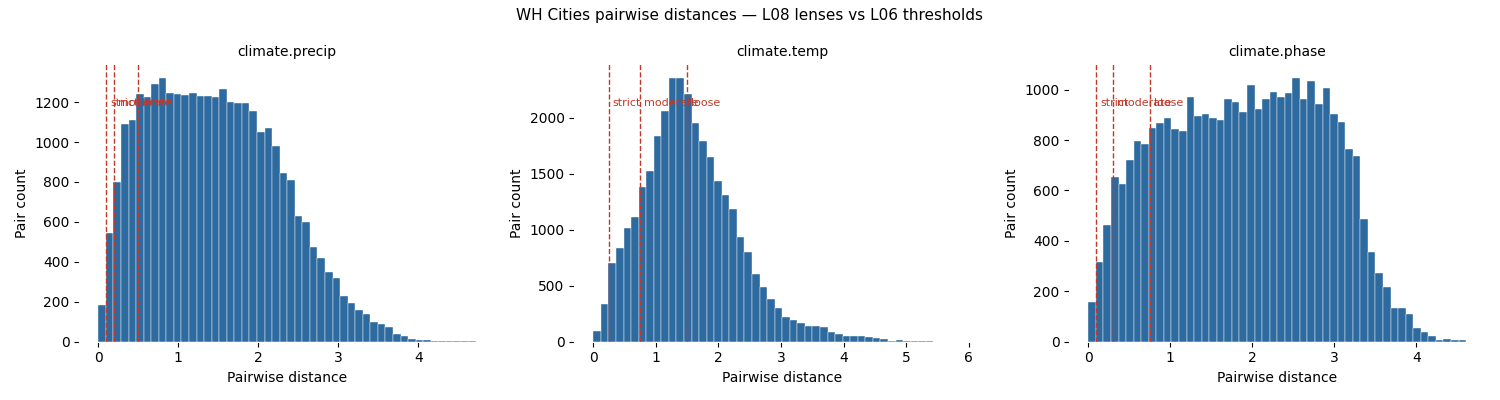

In [13]:
# Cell 9 — Pairwise distance histograms (WH Cities corpus, all three lenses)
# Stores pair_dist matrices in pair_dists dict for Cell 10 stats.

from IPython.display import Image as IPImage

pair_dists = {}
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, lid in zip(axes, LENS_VARS):
    state = lens_state08[lid]
    if state['metric'] == 'euclidean':
        Xc = state['Xz'][whc_idx]
        diffs = Xc[:, None, :] - Xc[None, :, :]
        pair_dist = np.sqrt(np.nansum(diffs**2, axis=2))
    else:
        Xc = state['X_raw'][whc_idx]
        pair_dist = np.zeros((len(whc_idx), len(whc_idx)))
        for i in range(len(whc_idx)):
            diff = Xc - Xc[i]
            d2 = np.einsum('ij,jk,ik->i', diff, state['VI'], diff)
            pair_dist[i] = np.where(d2 >= 0, np.sqrt(d2), np.nan)
    pair_dists[lid] = pair_dist

    upper = pair_dist[np.triu_indices(len(whc_idx), k=1)]
    upper = upper[np.isfinite(upper)]
    ax.hist(upper, bins=50, color='#2d6a9f', edgecolor='white', lw=0.3)
    for label, r in L06_THRESHOLDS[lid].items():
        ax.axvline(r, ls='--', color='#c0392b', lw=1)
        ax.text(r + upper.max()*0.01, ax.get_ylim()[1]*0.85,
                label, fontsize=8, color='#c0392b')
    ax.set_xlabel('Pairwise distance', color='black')
    ax.set_ylabel('Pair count', color='black')
    ax.set_title(lid, fontsize=10, color='black')
    ax.tick_params(colors='black')

fig.patch.set_facecolor('white')
for ax in axes:
    ax.set_facecolor('white')
fig.suptitle('WH Cities pairwise distances — L08 lenses vs L06 thresholds',
             color='black', fontsize=11)
fig.tight_layout()
outpath = OUT / 'l08_whc_pairwise_all_lenses.png'
fig.savefig(outpath, facecolor='white')
plt.close(fig)
display(IPImage(str(outpath)))

In [14]:
# Cell 10 — Peer count stats from pair_dists (text only — separate from image cell)
for lid in LENS_VARS:
    pair_dist = pair_dists[lid]
    print(f'\n{lid}')
    for label, r in L06_THRESHOLDS[lid].items():
        counts = (pair_dist <= r).sum(axis=1) - 1  # exclude self
        print(f'  {label}: median peers={np.median(counts):.0f}  '
              f'min={counts.min()}  max={counts.max()}  '
              f'pct_zero={100*(counts==0).mean():.0f}%')


climate.precip
  strict: median peers=1  min=0  max=7  pct_zero=36%
  moderate: median peers=5  min=0  max=21  pct_zero=10%
  loose: median peers=24  min=0  max=78  pct_zero=1%

climate.temp
  strict: median peers=2  min=0  max=15  pct_zero=19%
  moderate: median peers=30  min=0  max=83  pct_zero=1%
  loose: median peers=148  min=2  max=205  pct_zero=0%

climate.phase
  strict: median peers=1  min=0  max=8  pct_zero=39%
  moderate: median peers=8  min=0  max=24  pct_zero=2%
  loose: median peers=36  min=6  max=64  pct_zero=0%


In [ ]:
# Cell 11 — Summary / decision notes

# A. BUILD FEASIBILITY — VIABLE
#    Arrays (v_basin08_persist_rev2): 2.4 s, 36.6 MB
#    Derived variable compute: 0.03 s, 6.1 MB; 719 NaN (0.4%) in pre-based vars (hyper-arid)
#    Scalars (basin08): 1.6 s, 0 NaN
#    Per-lens build: 0.01 s each; total lens state 17 MB
#    Total startup: ~4 s, ~17 MB steady-state — viable alongside existing L06 index

# B. QUERY PERFORMANCE — FINE
#    Per-query distance array: 2.4–4.5 ms across all three lenses
#    Well inside any request/response budget

# C. THRESHOLD TRANSFER — DO NOT USE L06 THRESHOLDS AT L08
#    Same radii return ~10× more L08 basins in absolute terms (11.6× more basins)
#    Proportionally similar for precip/phase but climate.temp/loose captures 46% of all L08
#    basins — spatially autocorrelated thermal regimes make loose threshold effectively global
#    Conclusion: L06 thresholds do not transfer; recalibration required for global L08 display

# D. TOPN vs THRESHOLD FOR WH CITIES — USE TOPN=5
#    Within-corpus (254 cities) peer counts at L06 thresholds:
#
#    climate.precip  strict: median=1, 36% zero  |  moderate: median=5, 10% zero  |  loose: median=24
#    climate.temp    strict: median=2, 19% zero  |  moderate: median=30, 1% zero  |  loose: median=148
#    climate.phase   strict: median=1, 39% zero  |  moderate: median=8, 2% zero   |  loose: median=36
#
#    Problems with threshold mode for this corpus:
#    - strict returns zero peers for 36–39% of cities (precip/phase) — broken UX for a demo
#    - loose temp returns median 148/254 peers — not discrimination, noise
#    - no single threshold gives consistent density across all three lenses
#
#    topN=5 rationale:
#    - Never returns zero; consistent UX across all lenses
#    - Matches what moderate precip/phase naturally return for the median city
#    - Current workbench already uses limit=5 for whc-similar queries
#    - Honest label: "5 most similar cities in this collection"
#      (scope is corpus-relative, not a global similarity neighborhood)

print('Summary complete — all four questions answered.')
print()
print('Next: merge l08 → demo, close DEMO phase, open CDOP branch.')